In [35]:
# softmax回归实际上是一个多类逻辑回归模型，也就是说其实是个多分类模型
# 回归估计一个连续值，而分类预测一个离散类别

In [36]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

In [37]:
# 通过ToTensor将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0到1之间
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

len(mnist_train), len(mnist_test)

(60000, 10000)

In [38]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [39]:
def get_fashion_mnist_labels(labels):  #@save
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels] # 列表推导式: 对labels中的每个元素i, 转换为int类型, 并返回text_labels中对应的元素
# 列表推导式的具体公式：[对变量进行的操作 for 变量 in 列表]


In [40]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@save
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale) # 每个子图的大小为scale倍的num_cols和num_rows

    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize) # 创建一个num_rows行num_cols列的子图网格, 每个子图的大小为figsize，忽略图形对象，只返回子图对象数组axes

    axes = axes.flatten() # 将axes转换为一维数组, 方便后续遍历

    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

array([<AxesSubplot:title={'center':'ankle boot'}>,
       <AxesSubplot:title={'center':'t-shirt'}>,
       <AxesSubplot:title={'center':'t-shirt'}>,
       <AxesSubplot:title={'center':'dress'}>,
       <AxesSubplot:title={'center':'t-shirt'}>,
       <AxesSubplot:title={'center':'pullover'}>,
       <AxesSubplot:title={'center':'sneaker'}>,
       <AxesSubplot:title={'center':'pullover'}>,
       <AxesSubplot:title={'center':'sandal'}>,
       <AxesSubplot:title={'center':'sandal'}>,
       <AxesSubplot:title={'center':'t-shirt'}>,
       <AxesSubplot:title={'center':'ankle boot'}>,
       <AxesSubplot:title={'center':'sandal'}>,
       <AxesSubplot:title={'center':'sandal'}>,
       <AxesSubplot:title={'center':'sneaker'}>,
       <AxesSubplot:title={'center':'ankle boot'}>,
       <AxesSubplot:title={'center':'trouser'}>,
       <AxesSubplot:title={'center':'t-shirt'}>,
       <AxesSubplot:title={'center':'shirt'}>,
       <AxesSubplot:title={'center':'coat'}>,
       <AxesSubplot:

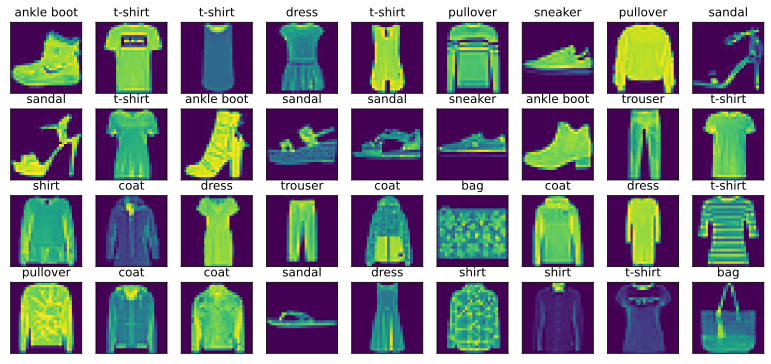

In [41]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=36))) # next函数返回迭代器的下一个项目要和iter函数配合使用 next(iterable[,default]) 其中iterable是一个可迭代对象
show_images(X.reshape(36, 28, 28),4,9, titles=get_fashion_mnist_labels(y))

In [42]:
# 为了使我们在读取训练集和测试集时更容易，我们使用内置的数据迭代器，而不是从零开始创建。 回顾一下，在每次迭代中，数据加载器每次都会读取一小批量数据，大小为batch_size。 通过内置数据迭代器，我们可以随机打乱了所有样本，从而无偏见地读取小批量。

In [43]:
batch_size = 256
def get_dataloader_workers(): #@save
    """使用4个进程来读取数据"""
    return 4
train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers())

In [44]:
time = d2l.Timer()
for X, y in train_iter:
    continue
f'{time.stop():.2f} sec'

'6.73 sec'

In [45]:
def load_data_fashion_mnist(batch_size, resize=None):  #@save
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [46]:
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


In [47]:
import torch
from IPython import display
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

In [48]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition  # 这里应用了广播机制

In [49]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.2639, 0.0908, 0.1913, 0.4149, 0.0391],
         [0.1051, 0.4652, 0.1620, 0.2253, 0.0424]]),
 tensor([1.0000, 1.0000]))

In [50]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

In [51]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y] #相当于是行索引是[0, 1]，列索引是[0, 2]意思是取出第0行第0列的元素和第1行第2列的元素

tensor([0.1000, 0.5000])

In [52]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

In [53]:
def accuracy(y_hat, y):  #@save
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())
accuracy(y_hat, y)/len(y)


0.5

In [54]:
def evaluate_accuracy(net, data_iter):  #@save
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    metric = Accumulator(2)  # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [55]:
class Accumulator:  #@save
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
evaluate_accuracy(net, test_iter)

0.1101

In [56]:
def train_epoch_ch3(net, train_iter, loss, updater):  #@save
    """训练模型一个迭代周期（定义见第3章）"""
    # 将模型设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 训练损失总和、训练准确度总和、样本数
    metric = Accumulator(3)
    for X, y in train_iter:
        # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]

In [57]:
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [58]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

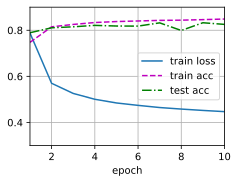

In [59]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

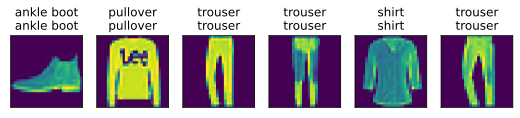

In [60]:
def predict_ch3(net, test_iter, n=6):  #@save
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)

In [61]:
# softmax回归的简洁实现
import torch
from torch import nn
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)


In [62]:
# pytorch不会隐式地调整输入的形状
# 因此，我们需要在线性层前添加一个展平层（flatten layer），来调整网络的输入形状
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weights) # 遍历网络的所有层，对每个线性层初始化权重

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

In [ ]:
loss = nn.CrossEntropyLoss() # 交叉熵损失函数 对每个样本计算损失然后再取平均
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

num_epochs =10
# 训练函数
def train(net, train_iter, test_iter, loss, num_epochs, optimizer):
    for epoch in range(num_epochs):
        net.train() # 训练模式
        total_loss = 0
        total_correct = 0 # 记录训练集上的正确预测数
        total_samples = 0 # 记录训练集上的总样本数

        for X, y in train_iter:
            y_hat = net(X)
            l = loss(y_hat, y)

            optimizer.zero_grad()
            l.backward()
            optimizer.step()
            
            # 计算当前批次的损失 因为每次计算的是一个批次的损失 所以需要将其转换为浮点数
            total_loss += l.item() # item函数将张量转换为Python标量 也就是说将损失从张量转换为浮点数
            total_correct += (y_hat.argmax(dim=1) == y).sum().item()
            total_samples += y.shape[0]
        test_acc = evaluate_accuracy(net, test_iter)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/total_samples:.4f}, Train Acc: {total_correct/total_samples:.4f}, Test Acc: {test_acc:.4f}")


In [72]:
def evaluate_accuracy(net, data_iter):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            correct += (y_hat.argmax(1) == y).sum().item()
            total += y.shape[0]
    return correct / total

# 7. 开始训练
num_epochs = 10
train(net, train_iter, test_iter, loss, num_epochs, optimizer)


Epoch 1/10, Loss: 0.0016, Train Acc: 0.8618, Test Acc: 0.8314
Epoch 2/10, Loss: 0.0016, Train Acc: 0.8611, Test Acc: 0.8421
Epoch 3/10, Loss: 0.0016, Train Acc: 0.8614, Test Acc: 0.8399
Epoch 4/10, Loss: 0.0016, Train Acc: 0.8611, Test Acc: 0.8423
Epoch 5/10, Loss: 0.0016, Train Acc: 0.8618, Test Acc: 0.8372
Epoch 6/10, Loss: 0.0016, Train Acc: 0.8619, Test Acc: 0.8371
Epoch 7/10, Loss: 0.0016, Train Acc: 0.8620, Test Acc: 0.8412
Epoch 8/10, Loss: 0.0016, Train Acc: 0.8615, Test Acc: 0.8413
Epoch 9/10, Loss: 0.0016, Train Acc: 0.8626, Test Acc: 0.8400
Epoch 10/10, Loss: 0.0016, Train Acc: 0.8630, Test Acc: 0.8338
